# 03 — Exploratory Data Analysis

Notebook 02 ended on a loose end. When we compared congestion thresholds fitted on
the first training fold against thresholds fitted on the whole six months, they
disagreed badly — the "Critical" line for `CHINng,IPLSng` came out at **34%** on
the training window but **8.8%** over the full series. We called it a *regime
shift* and moved on.

This notebook goes back and looks properly. The headline: **"regime shift" is the
wrong description**, and the real explanation matters for how we split the data.

We also do the standard exploratory work — utilisation over time, per-link
distributions, correlation between links, and when congestion actually happens.

**We are not choosing the train/test split here.** That comes next. The job of
this notebook is to make the picture clear enough to choose well.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd().parent
PROCESSED = PROJECT / "data" / "processed"

util = pd.read_parquet(PROCESSED / "abilene_link_utilization_wide.parquet")
util.index = pd.DatetimeIndex(util.index)

pd.set_option("display.width", 200)

print(f"{util.shape[0]:,} timesteps x {util.shape[1]} links")
print(f"{util.index.min():%Y-%m-%d} to {util.index.max():%Y-%m-%d}")

48,096 timesteps x 30 links
2004-03-01 to 2004-09-10


### Plot styling

A few colours defined once and reused, so every chart in the notebook looks the
same. These three are a colourblind-safe set — they stay distinguishable for
readers with deuteranopia or tritanopia, which a default matplotlib colour cycle
does not guarantee.

Every chart below is also printed as a table, so nothing depends on colour alone.

In [2]:
BLUE = "#2a78d6"     # main series
ORANGE = "#eb6834"   # second series / highlight
AQUA = "#1baf7a"     # third series
GREY = "#c3c2b7"     # background / de-emphasised lines
INK = "#0b0b0b"      # titles
MUTED = "#898781"    # axis labels

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,      # drop the box - it adds nothing
    "axes.spines.right": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": MUTED,
    "axes.titlecolor": INK,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "grid.color": "#e1e0d9",       # recessive grid...
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,        # ...drawn BEHIND the data, not through it
    "font.size": 9,
    "legend.frameon": False,
})
print("plot style set")

plot style set


## Part 1 — The whole six months in one plot

First, just look at it.

One important trick: we plot on the **complete 5-minute grid** (the same
`.asfreq("5min")` idea from notebook 02) rather than on the rows we have. Missing
periods become `NaN`, and matplotlib draws a **break in the line** instead of a
straight segment joining two points weeks apart. So the gaps are honestly visible
rather than papered over.

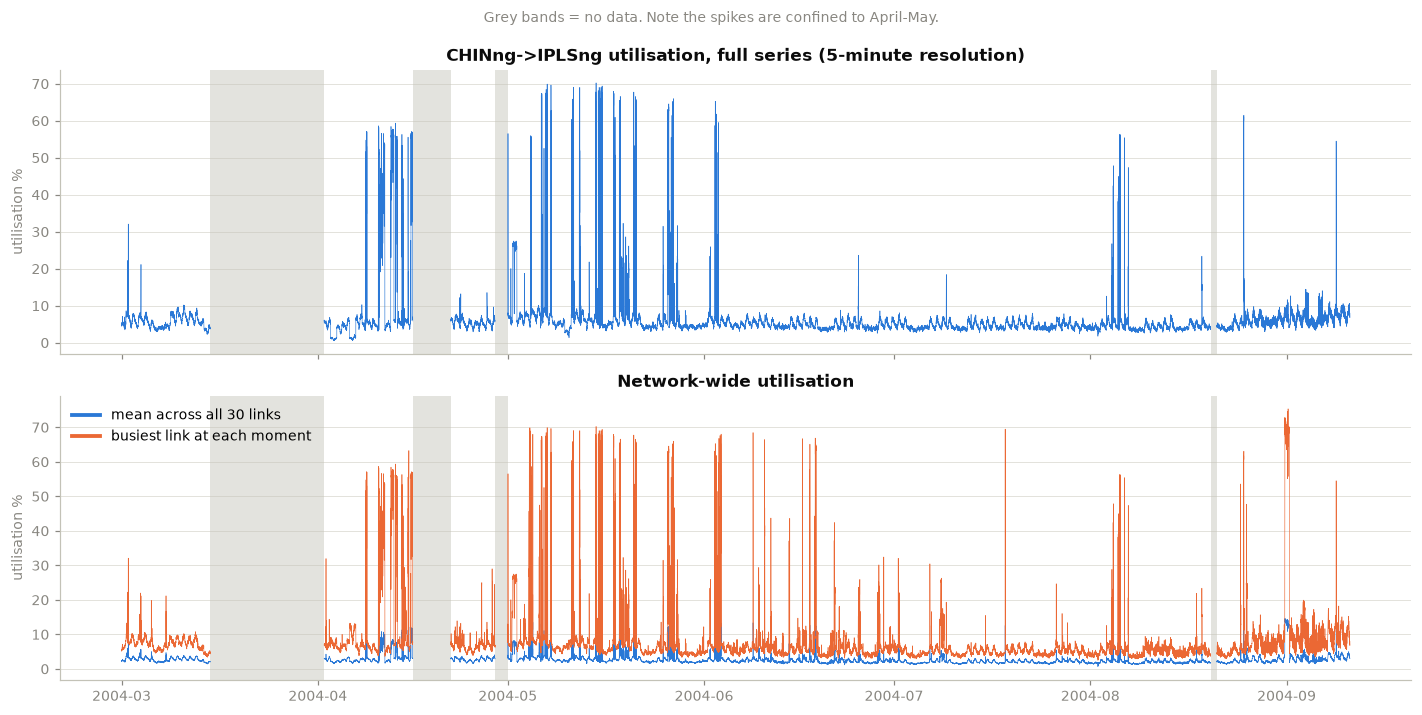

In [3]:
# Reindex onto the regular grid so gaps show up as breaks, not as fake straight lines.
grid = util.asfreq("5min")

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)

# Top: one busy link, at full 5-minute resolution.
axes[0].plot(grid.index, grid["CHINng,IPLSng"], color=BLUE, linewidth=0.4)
axes[0].set_title("CHINng->IPLSng utilisation, full series (5-minute resolution)")
axes[0].set_ylabel("utilisation %")
axes[0].grid(True, axis="y")

# Bottom: the network as a whole, so we can see whether it moves together.
axes[1].plot(grid.index, grid.mean(axis=1), color=BLUE, linewidth=0.4,
             label="mean across all 30 links")
axes[1].plot(grid.index, grid.max(axis=1), color=ORANGE, linewidth=0.4,
             label="busiest link at each moment")
axes[1].set_title("Network-wide utilisation")
axes[1].set_ylabel("utilisation %")
# The data lines are hair-thin so the series read cleanly at this density;
# thicken the legend swatches only, or they are unreadable.
legend = axes[1].legend(loc="upper left")
for handle in legend.get_lines():
    handle.set_linewidth(2.5)
axes[1].grid(True, axis="y")

# Shade the periods with no data at all.
missing_days = pd.date_range("2004-03-15", "2004-04-01"), \
               pd.date_range("2004-04-16", "2004-04-21"), \
               pd.date_range("2004-04-29", "2004-04-30"), \
               pd.date_range("2004-08-20", "2004-08-20")
for ax in axes:
    for block in missing_days:
        ax.axvspan(block[0], block[-1] + pd.Timedelta(days=1),
                   color=GREY, alpha=0.45, linewidth=0)

fig.suptitle("Grey bands = no data. Note the spikes are confined to April-May.",
             color=MUTED, y=0.99, fontsize=9)
plt.tight_layout()
plt.show()

Two things jump out immediately:

1. The busy period is **April and May**, and it is not one continuous block — the
   top panel looks like a series of tall, separate bursts.
2. The bottom panel shows the *mean* barely moves while the *maximum* explodes.
   Whatever is happening is **not** the whole network getting busier.

Both of those contradict the phrase "regime shift", which suggests the network
settled into a new, sustained state. Let us check properly.

## Part 2 — Investigating the "regime shift"

### 2a. Monthly percentiles, per link

For each month we compute the 50th percentile (a typical moment), the 95th
percentile (the busy tail — this is the line our "Critical" label sits on), and
the maximum.

In [4]:
month = util.index.to_period("M")

monthly_p50 = util.groupby(month).quantile(0.50)
monthly_p95 = util.groupby(month).quantile(0.95)
monthly_max = util.groupby(month).max()

LINK = "CHINng,IPLSng"

summary = pd.DataFrame({
    "p50 (typical)": monthly_p50[LINK],
    "p95 (busy tail)": monthly_p95[LINK],
    "max": monthly_max[LINK],
}).round(2)

print(f"{LINK}:")
print(summary.to_string())

CHINng,IPLSng:
         p50 (typical)  p95 (busy tail)    max
2004-03           5.55             8.30  32.09
2004-04           5.23            52.83  59.37
2004-05           5.61            26.79  70.24
2004-06           4.77             7.00  65.28
2004-07           4.37             6.52  18.43
2004-08           4.47             7.42  61.51
2004-09           6.44             9.97  54.52


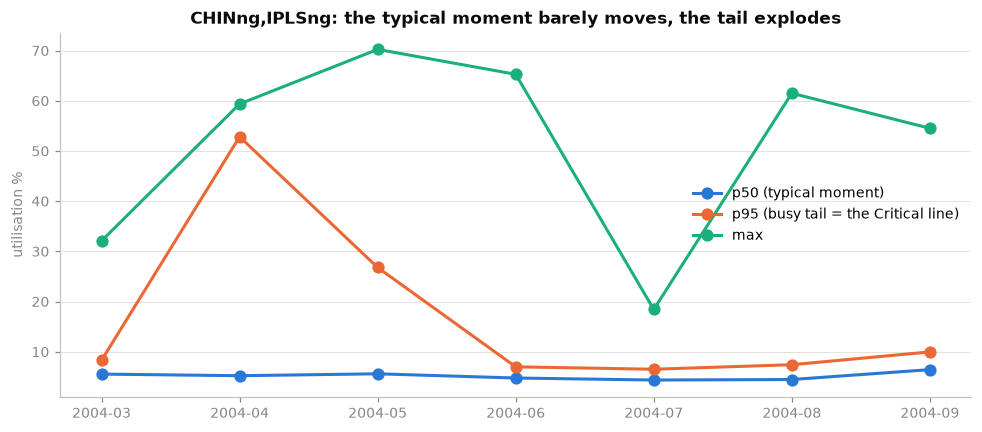

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))

x = np.arange(len(summary))
ax.plot(x, summary["p50 (typical)"], marker="o", color=BLUE, linewidth=2,
        markersize=7, label="p50 (typical moment)")
ax.plot(x, summary["p95 (busy tail)"], marker="o", color=ORANGE, linewidth=2,
        markersize=7, label="p95 (busy tail = the Critical line)")
ax.plot(x, summary["max"], marker="o", color=AQUA, linewidth=2,
        markersize=7, label="max")

ax.set_xticks(x)
ax.set_xticklabels([str(p) for p in summary.index])
ax.set_ylabel("utilisation %")
ax.set_title(f"{LINK}: the typical moment barely moves, the tail explodes")
ax.legend()
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

This is the key shape. **The median (p50) is almost flat all year.** The p95 and
the max are what move, and they move by a factor of eight.

In other words: on a typical April afternoon this link looked completely normal.
What April had that July did not was a handful of extreme moments.

### 2b. Is it the whole network, or a few links?

Plot every link's monthly p95 on one chart. If this were a network-wide shift,
all 30 lines would rise together.

The first version of this chart was titled *"only five links move"* — which the
chart itself disproved, because in September a **different** set of grey lines
rises above the highlighted ones. Both sets are now coloured.

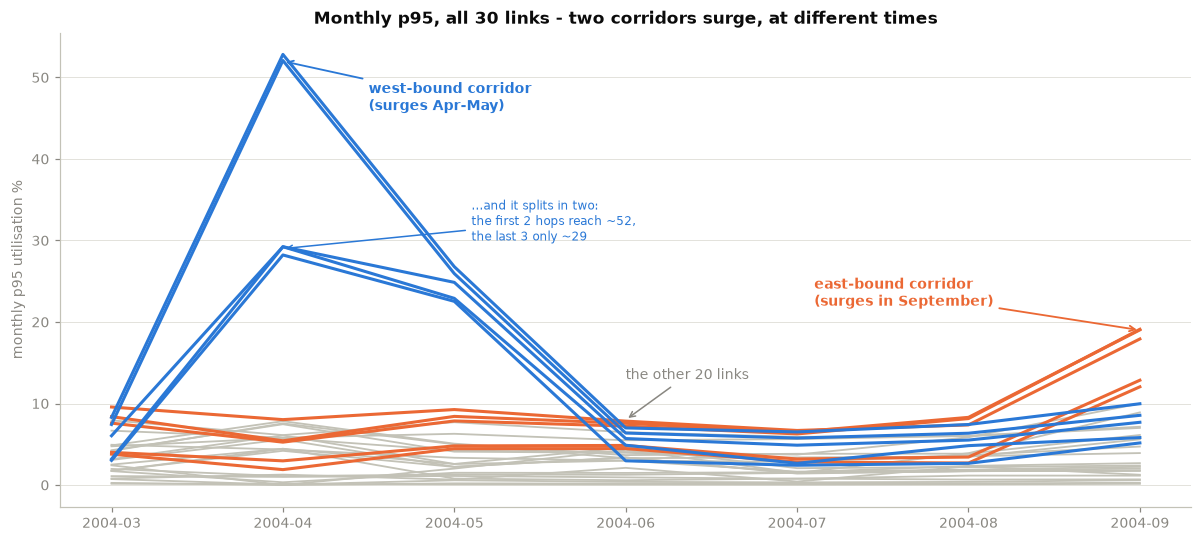

In [6]:
# The five west-bound links that surge in April/May...
CORRIDOR = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,DNVRng",
            "DNVRng,SNVAng", "SNVAng,LOSAng"]
# ...and the same five links east-bound, which do something different.
CORRIDOR_EAST = ["IPLSng,CHINng", "KSCYng,IPLSng", "DNVRng,KSCYng",
                 "SNVAng,DNVRng", "LOSAng,SNVAng"]

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(monthly_p95))

# Everything else in grey, drawn first so the two highlighted sets sit on top.
for link in monthly_p95.columns:
    if link not in CORRIDOR and link not in CORRIDOR_EAST:
        ax.plot(x, monthly_p95[link], color=GREY, linewidth=1.2, zorder=1)

for link in CORRIDOR:
    ax.plot(x, monthly_p95[link], color=BLUE, linewidth=2, zorder=3)
for link in CORRIDOR_EAST:
    ax.plot(x, monthly_p95[link], color=ORANGE, linewidth=2, zorder=2)

# Direct labels rather than a 30-entry legend.
ax.annotate("west-bound corridor\n(surges Apr-May)", xy=(1, 52), xytext=(1.5, 46),
            color=BLUE, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=BLUE, linewidth=1.2))
ax.annotate("...and it splits in two:\nthe first 2 hops reach ~52,\n"
            "the last 3 only ~29", xy=(1, 29), xytext=(2.1, 30),
            color=BLUE, fontsize=8,
            arrowprops=dict(arrowstyle="->", color=BLUE, linewidth=1))
ax.annotate("east-bound corridor\n(surges in September)", xy=(6, 19),
            xytext=(4.1, 22), color=ORANGE, fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=ORANGE, linewidth=1.2))
ax.annotate("the other 20 links", xy=(3, 8), xytext=(3.0, 13), color=MUTED,
            fontsize=9, arrowprops=dict(arrowstyle="->", color=MUTED, linewidth=1))

ax.set_xticks(list(x))
ax.set_xticklabels([str(p) for p in monthly_p95.index])
ax.set_ylabel("monthly p95 utilisation %")
ax.set_title("Monthly p95, all 30 links - two corridors surge, at different times")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [7]:
# How much does each link's p95 vary between its busiest and quietest month?
spread = (monthly_p95.max() / monthly_p95.min().replace(0, np.nan)).sort_values(ascending=False)
print("ratio of busiest month p95 to quietest month p95:\n")
print(spread.head(10).round(1).to_string())

ratio of busiest month p95 to quietest month p95:

link
HSTNng,LOSAng    437.3
HSTNng,KSCYng     15.2
DNVRng,SNVAng     11.6
SNVAng,LOSAng     11.0
IPLSng,KSCYng      9.0
STTLng,DNVRng      8.2
CHINng,IPLSng      8.1
DNVRng,STTLng      8.0
KSCYng,HSTNng      7.6
SNVAng,DNVRng      6.4


Two separate stories are now visible in one chart:

- **Blue (west-bound)** surges in April and May, then returns to the pack.
- **Orange (east-bound)** is flat through the spring and rises in **September**,
  where it goes *above* the blue lines.

So the April episode is not the only one — there is a second, smaller, opposite-
direction event at the end of the series. Whatever produces these is a **recurring
kind of event on this network**, not a one-off anomaly we could justify deleting.

Note also that the blue lines split into two tiers in April (~52 and ~29). That is
a clue we come back to in 2c.

### The five links are not a random selection — they are one path

Look at what those links are, in order:

```
CHIN -> IPLS -> KSCY -> DNVR -> SNVA -> LOSA
Chicago  Indianapolis  Kansas City  Denver  Sunnyvale  Los Angeles
```

They form a **single continuous west-bound route across the United States**. That
is the signature of one (or a few) very large origin–destination flows — a bulk
data transfer between two sites — not a general increase in network activity.

The strongest confirmation: **the reverse direction is unaffected.**

In [8]:
westbound = ["CHINng,IPLSng", "IPLSng,KSCYng", "KSCYng,DNVRng"]
eastbound = ["IPLSng,CHINng", "KSCYng,IPLSng", "DNVRng,KSCYng"]

print("monthly p95, west-bound (the affected direction):")
print(monthly_p95[westbound].round(2).to_string())
print("\nmonthly p95, the SAME links east-bound:")
print(monthly_p95[eastbound].round(2).to_string())

monthly p95, west-bound (the affected direction):
link     CHINng,IPLSng  IPLSng,KSCYng  KSCYng,DNVRng
2004-03           8.30           7.42           6.04
2004-04          52.83          52.09          29.24
2004-05          26.79          25.94          24.86
2004-06           7.00           6.38           5.70
2004-07           6.52           5.76           4.89
2004-08           7.42           6.36           5.51
2004-09           9.97           8.55           7.70

monthly p95, the SAME links east-bound:
link     IPLSng,CHINng  KSCYng,IPLSng  DNVRng,KSCYng
2004-03           9.57           8.39           7.59
2004-04           8.02           5.42           5.26
2004-05           9.26           8.42           7.86
2004-06           7.84           7.58           7.23
2004-07           6.69           6.50           6.27
2004-08           7.37           8.30           8.15
2004-09          17.92          19.03          19.11


West-bound jumps from ~8% to ~52% in April. East-bound over the same links sits at
~8–9% and does not budge.

Traffic on a link is directional, and only one direction carries the surge. A
general "the network got busier" story cannot produce that. One large one-way
transfer can.

### 2c. Sudden or gradual? Neither — it switches on and off

Monthly averages hide the shape. Look week by week, then day by day.

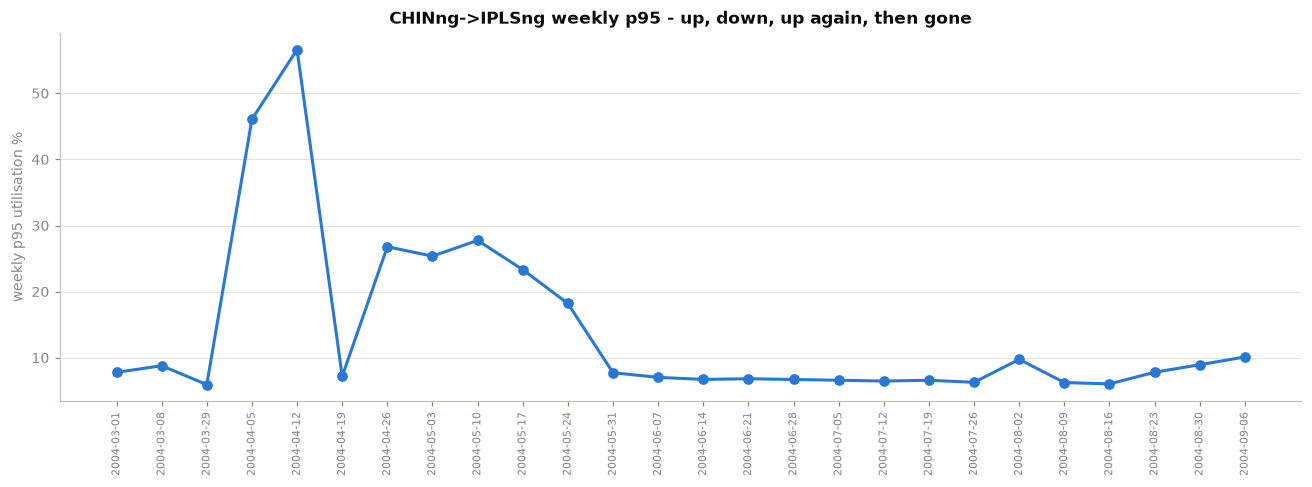

2004-03-01/2004-03-07     7.78
2004-03-08/2004-03-14     8.79
2004-03-29/2004-04-04     5.94
2004-04-05/2004-04-11    46.07
2004-04-12/2004-04-18    56.61
2004-04-19/2004-04-25     7.18
2004-04-26/2004-05-02    26.78
2004-05-03/2004-05-09    25.36
2004-05-10/2004-05-16    27.74
2004-05-17/2004-05-23    23.32
2004-05-24/2004-05-30    18.20
2004-05-31/2004-06-06     7.73
2004-06-07/2004-06-13     7.03
2004-06-14/2004-06-20     6.72
2004-06-21/2004-06-27     6.81
2004-06-28/2004-07-04     6.70
2004-07-05/2004-07-11     6.59
2004-07-12/2004-07-18     6.47
2004-07-19/2004-07-25     6.58
2004-07-26/2004-08-01     6.27
2004-08-02/2004-08-08     9.75
2004-08-09/2004-08-15     6.24
2004-08-16/2004-08-22     6.03
2004-08-23/2004-08-29     7.80
2004-08-30/2004-09-05     8.93
2004-09-06/2004-09-12    10.11
Freq: W-SUN


In [9]:
weekly_p95 = util.groupby(util.index.to_period("W")).quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(range(len(weekly_p95)), weekly_p95["CHINng,IPLSng"],
        marker="o", color=BLUE, linewidth=2, markersize=6)
ax.set_xticks(range(len(weekly_p95)))
ax.set_xticklabels([str(p).split("/")[0] for p in weekly_p95.index],
                   rotation=90, fontsize=7)
ax.set_ylabel("weekly p95 utilisation %")
ax.set_title("CHINng->IPLSng weekly p95 - up, down, up again, then gone")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

print(weekly_p95["CHINng,IPLSng"].round(2).to_string())

This is the finding that changes the story. The sequence is:

| Week | p95 |
|---|---|
| 29 Mar – 4 Apr | 5.9 (normal) |
| 5 – 11 Apr | **46.1** |
| 12 – 18 Apr | **56.6** |
| 19 – 25 Apr | 7.2 (**back to normal**) |
| 26 Apr – 2 May | **26.8** |
| May | 25 → 18, declining |
| 31 May onwards | 7.7 (normal, stays normal) |

It goes **up, back down to baseline, up again, then decays away**. That is not a
shift from one regime to another — it is an intermittent activity that appears,
pauses, returns, and finishes.

At daily resolution it is even more clearly on/off.

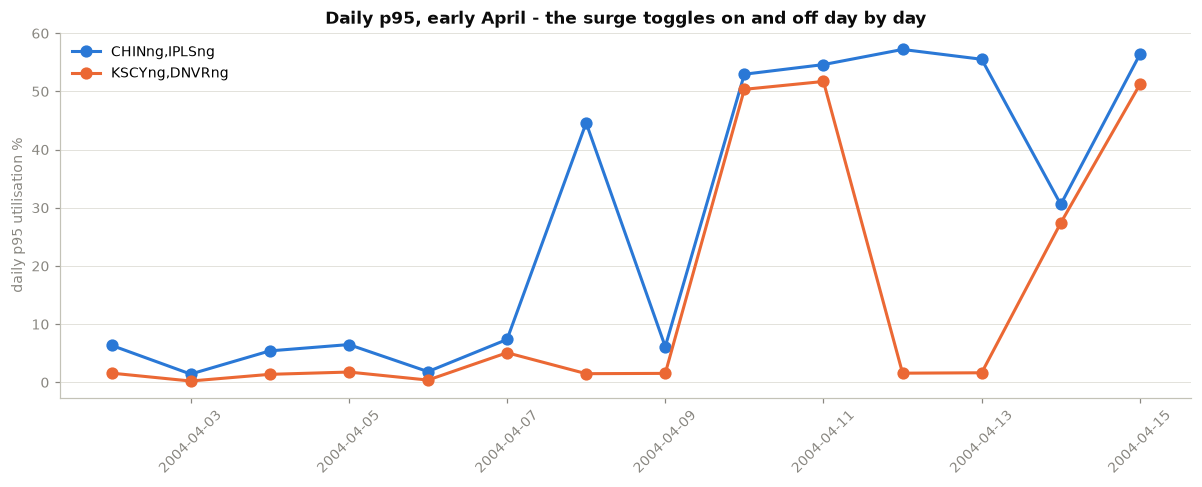

link        CHINng,IPLSng  IPLSng,KSCYng  KSCYng,DNVRng  DNVRng,SNVAng  SNVAng,LOSAng
2004-04-02            6.4            4.9            1.6            0.3            1.5
2004-04-03            1.4            0.8            0.2            0.2            1.1
2004-04-04            5.4            4.5            1.4            0.2            1.1
2004-04-05            6.5            5.7            1.8            0.3            1.6
2004-04-06            1.8            0.8            0.4            0.4            1.4
2004-04-07            7.4            6.8            5.1            3.4            1.1
2004-04-08           44.6           44.1            1.5            0.3            1.5
2004-04-09            6.1            4.8            1.5            0.2            1.5
2004-04-10           53.0           52.2           50.4           49.6           50.3
2004-04-11           54.6           54.1           51.7           50.8           51.7
2004-04-12           57.2           55.6            1.

In [10]:
daily_p95 = util.groupby(util.index.normalize()).quantile(0.95)
april = daily_p95.loc["2004-04-02":"2004-04-15", CORRIDOR]

fig, ax = plt.subplots(figsize=(11, 4.5))
for link, colour in zip(["CHINng,IPLSng", "KSCYng,DNVRng"], [BLUE, ORANGE]):
    ax.plot(april.index, april[link], marker="o", linewidth=2,
            markersize=7, color=colour, label=link)
ax.set_ylabel("daily p95 utilisation %")
ax.set_title("Daily p95, early April - the surge toggles on and off day by day")
ax.legend()
ax.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(april.round(1).to_string())

Two separate things are visible here, and the second one is easy to miss.

**First: it toggles daily.** 8 April is 44.6, 9 April is back to 6.1, 10 April is
53.0. This is a process that runs on some days and not others.

**Second: not all five links light up on the same days.** On 8 April,
`CHIN->IPLS` and `IPLS->KSCY` are at ~44 while `KSCY->DNVR` is at 1.5. On 10 April
all five are at ~50.

So there are at least **two different large flows** using overlapping parts of the
same route — one that leaves the backbone around Kansas City, and one that runs
the full width of the country to Los Angeles. They are active on different days.

We cannot confirm this from link loads alone; it would need the origin–destination
matrix broken out per flow, which we have but have not analysed here. Stated as
the most likely reading, not as established fact.

### 2d. Do the gaps line up with the transitions?

This matters. If the missing days sit exactly where the behaviour changes, we
cannot tell what actually happened at those transitions.

Missing periods: **15 Mar – 1 Apr**, **16 – 21 Apr**, **29 – 30 Apr**, **20 Aug**.

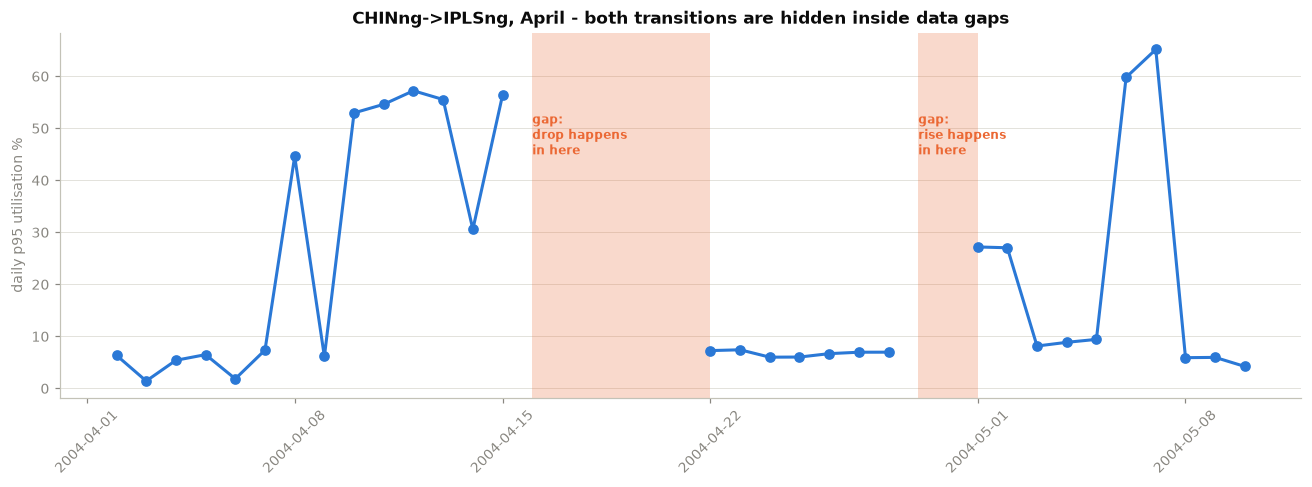

In [11]:
zoom = daily_p95.loc["2004-04-01":"2004-05-10", "CHINng,IPLSng"]
# Put the missing days back in as NaN so the line breaks where data is absent.
zoom = zoom.reindex(pd.date_range("2004-04-01", "2004-05-10", freq="D"))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(zoom.index, zoom.to_numpy(), marker="o", color=BLUE,
        linewidth=2, markersize=6)

for start, end, label in [("2004-04-16", "2004-04-21", "gap:\ndrop happens\nin here"),
                          ("2004-04-29", "2004-04-30", "gap:\nrise happens\nin here")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end) + pd.Timedelta(days=1),
               color=ORANGE, alpha=0.25, linewidth=0)
    ax.annotate(label, xy=(pd.Timestamp(start), 45), color=ORANGE,
                fontsize=8, fontweight="bold")

ax.set_ylabel("daily p95 utilisation %")
ax.set_title("CHINng->IPLSng, April - both transitions are hidden inside data gaps")
ax.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Yes — and this is an uncomfortable answer.**

- The **start** of the surge (8 April) is clean. We have data either side of it,
  and it genuinely begins abruptly.
- The **end** of the first burst falls inside the 16–21 April gap. We see ~56% on
  15 April and ~7% on 22 April, and nothing in between. Whether it stopped
  abruptly or wound down over those six days is **unknowable from this data**.
- The **return** of the second burst falls inside the 29–30 April gap. Same
  problem.

So of the three transitions, we can only actually observe one. We should not claim
the bursts start and stop abruptly — we can only say that *one* of them did, and
the other two changed state while we were not looking.

The 18-day March gap is a separate issue: it sits *before* the interesting period
and does not hide a transition, but it does mean we have only two weeks of "before"
to compare against.

### 2e. Something we cannot explain

While looking at the monthly tables, a few links go **quiet** in April at the same
time as the corridor surges.

In [12]:
quiet_in_april = ["HSTNng,LOSAng", "HSTNng,KSCYng", "ATLAng,ATLA-M5", "DNVRng,STTLng"]
print("monthly MEAN utilisation % for links that drop in April:")
print(util.groupby(month)[quiet_in_april].mean().round(3).to_string())

print("\ncount of readings that are exactly zero:")
zeros = (util == 0).sum()
print(zeros[zeros > 0].sort_values(ascending=False).to_string())

monthly MEAN utilisation % for links that drop in April:
link     HSTNng,LOSAng  HSTNng,KSCYng  ATLAng,ATLA-M5  DNVRng,STTLng
2004-03          1.451          0.469           0.111          1.204
2004-04          0.004          0.022           0.000          0.180
2004-05          1.569          0.315           0.087          1.040
2004-06          1.633          0.215           0.071          1.081
2004-07          0.934          0.193           0.068          1.080
2004-08          1.168          0.223           0.086          1.217
2004-09          1.267          0.397           0.140          1.841

count of readings that are exactly zero:
link
ATLAng,ATLA-M5    6337
HSTNng,LOSAng        9
ATLA-M5,ATLAng       2
HSTNng,KSCYng        1


`ATLAng->ATLA-M5` is **exactly zero for the whole of April** — not small, zero. It
also has 6,337 exactly-zero readings across the series, about 13% of its
observations. Every other link has at most nine.

We do not have a confirmed explanation. Two candidates:

- **A routing change.** If Abilene altered its IGP weights in April, traffic would
  move off some paths onto others. Note that our routing matrix `A` is a **single
  snapshot dated 2003-04-10** applied to all of 2004 — if the real routing changed,
  our computed loads would be wrong in exactly this kind of way.
- **A measurement or collection artefact** at that router.

`ATLA-M5` is an odd node anyway: it shares coordinates with `ATLAng`, so it is a
second router inside the same Atlanta site rather than a city on the backbone.

Flagging it rather than explaining it away. It affects one link pair with tiny
utilisation, so it will not distort the headline numbers — but "this link reads
exactly zero for a month and we do not know why" is the kind of thing that should
be written down, not smoothed over.

### 2f. Settling the two-flows question with the raw demand data

Part 2c inferred two separate flows from link-level behaviour. That was inference.
The origin–destination demands are in the raw files, so we can check it directly.

The test: at the busiest moment of **8 April** (only the first two corridor hops
were active) and of **10 April** (the whole corridor was active), which OD pairs
were actually sending the traffic? If the same pair dominates both, it is one
flow. If different pairs dominate, it is two.

In [13]:
import gzip

# Only the weeks we need: April (X03, X04), a quiet July baseline (X16, X17),
# and September (X24).
WEEK_START = {"X03": "2004-04-02", "X04": "2004-04-09", "X16": "2004-07-10",
              "X17": "2004-07-17", "X24": "2004-09-04"}

od_names = [line.split()[0]
            for line in (PROJECT / "data/raw/abilene/demands").read_text().splitlines()
            if line.strip() and not line.startswith("#")]

def load_week(name):
    with gzip.open(PROJECT / f"data/raw/abilene/traffic-matrices/{name}.gz", "rt") as fh:
        raw = np.loadtxt(fh)
    return pd.DataFrame(raw[:, 0::5] * (100 * 8 / 300 / 1000),   # -> kbps
                        columns=od_names,
                        index=pd.date_range(WEEK_START[name], periods=2016, freq="5min"))

demand = pd.concat([load_week(n) for n in WEEK_START]).sort_index()

# "Normal" level for each OD pair - July was the calmest month in Part 5.
baseline = demand.loc["2004-07-10":"2004-07-23"].median()

print(f"loaded {demand.shape[0]:,} timesteps x {demand.shape[1]} OD pairs")

loaded 10,080 timesteps x 144 OD pairs


In [14]:
# Rebuild the routing matrix so we can attribute a link's load back to OD pairs.
link_index = pd.read_csv(PROJECT / "data/raw/abilene/links", sep=r"\s+",
                         comment="#", names=["link", "link_idx", "link_type"])
A_long = pd.read_csv(PROJECT / "data/raw/abilene/A", sep=r"\s+", comment="#",
                     names=["link", "od", "link_idx", "demand_idx", "frac"])
A = np.zeros((link_index.link_idx.max(), len(od_names)))
A[A_long.link_idx - 1, A_long.demand_idx - 1] = A_long.frac
link_row = dict(zip(link_index.link, link_index.link_idx - 1))


def who_is_sending(day, link):
    """At the busiest moment of `day` on `link`, which OD pairs put traffic on it?"""
    contribution = demand.loc[day] * A[link_row[link]]     # kbps per OD, on this link
    peak = contribution.sum(axis=1).idxmax()
    table = pd.DataFrame({
        "Gbps_on_link": contribution.loc[peak] / 1e6,
        "x_above_july": demand.loc[peak] / baseline.replace(0, np.nan),
    })
    print(f"{link} on {day} - peak at {peak}, "
          f"{contribution.sum(axis=1).max() / 1e6:.2f} Gbps total")
    print(table.sort_values("Gbps_on_link", ascending=False).head(4).round(1).to_string())
    return table.sort_values("Gbps_on_link", ascending=False).index[0]


top_8th = who_is_sending("2004-04-08", "CHINng,IPLSng")
print()
top_10th = who_is_sending("2004-04-10", "CHINng,IPLSng")
print(f"\ndominant OD pair on  8 April: {top_8th}")
print(f"dominant OD pair on 10 April: {top_10th}")
print(f"same pair? {top_8th == top_10th}")

CHINng,IPLSng on 2004-04-08 - peak at 2004-04-08 17:15:00, 5.67 Gbps total
               Gbps_on_link  x_above_july
CHINng,HSTNng           5.2         575.5
WASHng,IPLSng           0.1           1.4
NYCMng,IPLSng           0.1           2.9
CHINng,IPLSng           0.1           2.0

CHINng,IPLSng on 2004-04-10 - peak at 2004-04-10 14:25:00, 5.82 Gbps total
               Gbps_on_link  x_above_july
CHINng,LOSAng           5.4         161.0
WASHng,IPLSng           0.1           1.5
CHINng,HSTNng           0.1           8.1
CHINng,IPLSng           0.0           1.4

dominant OD pair on  8 April: CHINng,HSTNng
dominant OD pair on 10 April: CHINng,LOSAng
same pair? False


**Different pairs, and it is not close.** Both are enormous — over 5 Gbps from a
single OD pair, against a July baseline of a few tens of Mbps — but they have
different destinations:

- **8 April:** `CHINng -> HSTNng` (Chicago → Houston), ~5.2 Gbps, **575×** its
  normal level.
- **10 April:** `CHINng -> LOSAng` (Chicago → Los Angeles), ~5.4 Gbps, **161×**
  its normal level.

Same origin PoP, different destination PoP. And the routing explains the link
pattern exactly.

In [15]:
# Which backbone links does each of those OD pairs actually traverse?
internal_links = set(link_index[link_index.link_type == 0].link)
for od in ["CHINng,HSTNng", "CHINng,LOSAng"]:
    hops = [l for l in A_long[A_long.od == od].link if l in internal_links]
    print(f"{od:<16} -> {'  '.join(hops)}")

CHINng,HSTNng    -> CHINng,IPLSng  IPLSng,KSCYng  KSCYng,HSTNng
CHINng,LOSAng    -> CHINng,IPLSng  DNVRng,SNVAng  IPLSng,KSCYng  KSCYng,DNVRng  SNVAng,LOSAng


This is the mechanism, confirmed:

- `CHINng->HSTNng` uses **CHIN→IPLS, IPLS→KSCY**, then turns south to Houston. It
  never touches KSCY→DNVR. That is precisely why on 8 April the first two hops read
  ~44% while `KSCY->DNVR` sat at 1.5%.
- `CHINng->LOSAng` uses **all five** corridor hops. That is why on 10 April the
  whole path lit up together.

The inference in Part 2c was correct, and we can now state it as fact rather than
as a reading of the correlation structure.

In [16]:
# Same question for the September east-bound episode.
who_is_sending("2004-09-07", "DNVRng,KSCYng")

DNVRng,KSCYng on 2004-09-07 - peak at 2004-09-07 14:35:00, 1.74 Gbps total
               Gbps_on_link  x_above_july
STTLng,CHINng           0.4          10.5
STTLng,IPLSng           0.3          31.6
STTLng,WASHng           0.2          23.9
STTLng,KSCYng           0.2          51.9


'STTLng,CHINng'

### September is a different kind of event

September does **not** look like April. There is no single dominant transfer.
Instead the top contributors are all **from the same origin, `STTLng` (Seattle),
to several different destinations** — Chicago, Indianapolis, Washington, Kansas
City, Atlanta — each elevated 10–50× above its July level.

It is also an order of magnitude smaller: ~0.4 Gbps for the largest pair, against
~5.4 Gbps in April.

So September is elevated **egress from one PoP spread across many destinations**,
not one point-to-point transfer. Both episodes concentrate on a corridor, but for
structurally different reasons.

### Verdict

**April: confirmed as two distinct flows.** Different origin–destination pairs
dominate the two days — `CHINng->HSTNng` on 8 April and `CHINng->LOSAng` on
10 April — and their different routes account for exactly which links lit up.

**September: also distinct, but not a second pair of point-to-point flows.** It is
a fan-out from `STTLng` across roughly five destinations, ~13× smaller in
magnitude.

These are city-level PoP names. Nothing in this dataset identifies who or what
sent the traffic, and we make no attempt to guess.

## Part 3 — Per-link distributions

Notebook 02 found the "Critical" threshold varies about 80× between the quietest
and busiest link. Here is that spread directly.

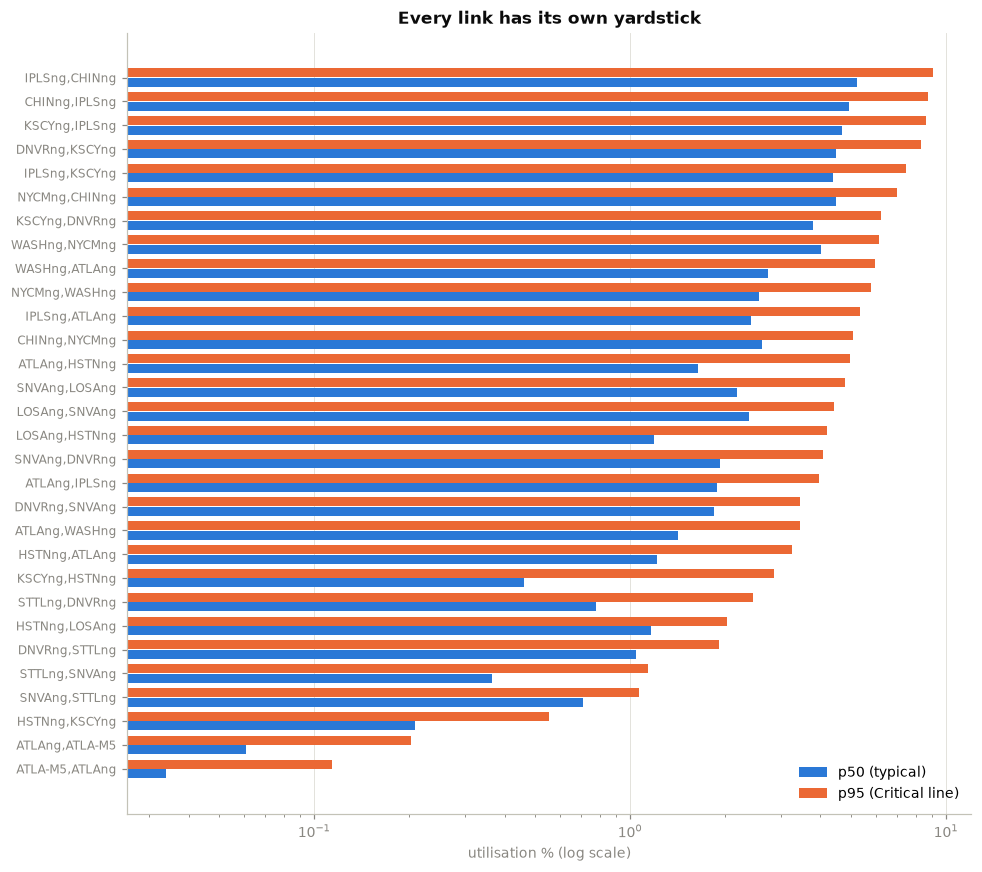

quietest link p95 : 0.114%  (ATLA-M5,ATLAng)
busiest link p95  : 9.081%  (IPLSng,CHINng)
ratio             : 80x


In [17]:
order = util.quantile(0.95).sort_values().index

fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(order))

ax.barh(y - 0.2, util.quantile(0.50)[order], height=0.38, color=BLUE,
        label="p50 (typical)")
ax.barh(y + 0.2, util.quantile(0.95)[order], height=0.38, color=ORANGE,
        label="p95 (Critical line)")

ax.set_yticks(y)
ax.set_yticklabels(order, fontsize=8)
ax.set_xscale("log")     # log scale: the range is far too wide for a linear axis
ax.set_xlabel("utilisation % (log scale)")
ax.set_title("Every link has its own yardstick")
ax.legend(loc="lower right")
ax.grid(True, axis="x")
plt.tight_layout()
plt.show()

thresholds = pd.DataFrame({"p50": util.quantile(0.50), "p95": util.quantile(0.95)})
print(f"quietest link p95 : {thresholds.p95.min():.3f}%  ({thresholds.p95.idxmin()})")
print(f"busiest link p95  : {thresholds.p95.max():.3f}%  ({thresholds.p95.idxmax()})")
print(f"ratio             : {thresholds.p95.max() / thresholds.p95.min():.0f}x")

An 80× spread, and it needs a **log scale** to be visible at all. This is exactly
why the labelling is per-link: a single network-wide threshold would mark the
quiet links as never congested and the busy ones as permanently congested.

## Part 4 — Do links get congested together?

If congestion were independent per link, rerouting would be easy — there would
always be a quiet neighbour to move traffic onto. If links congest in groups,
rerouting is harder and more interesting.

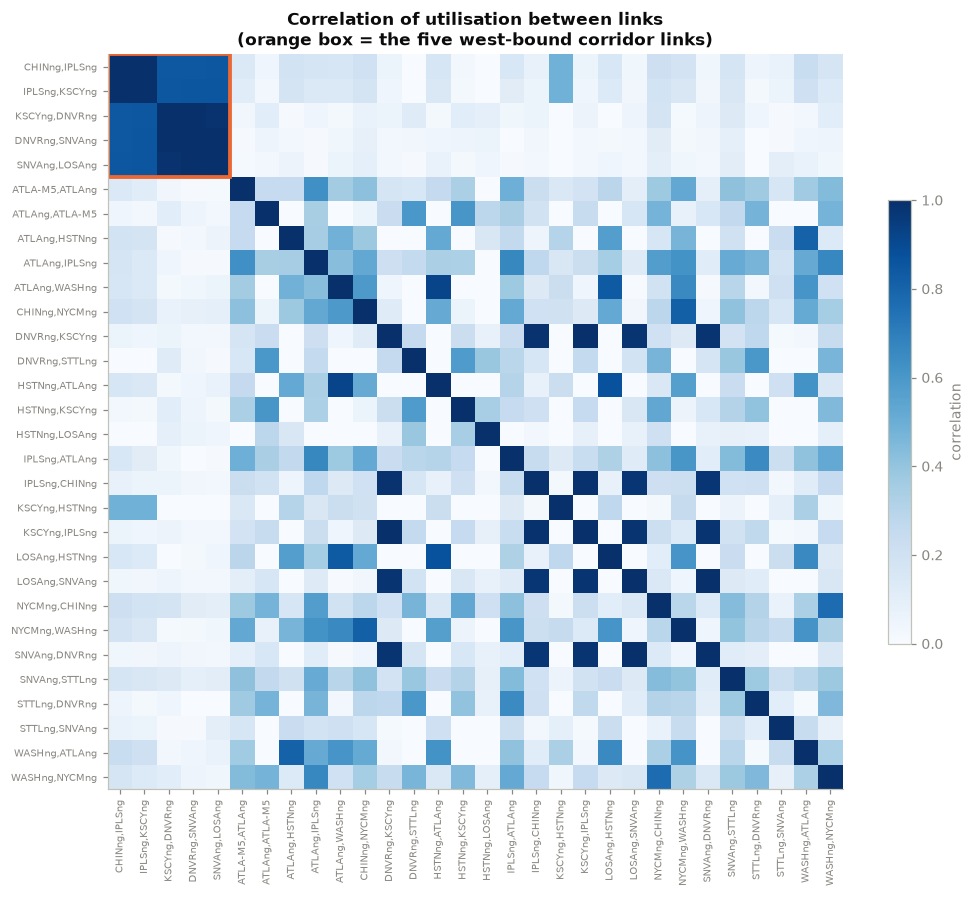

In [18]:
# Order the links so the west-bound corridor sits together - block structure
# in the matrix is then visible rather than scattered.
ordered = CORRIDOR + [c for c in util.columns if c not in CORRIDOR]
correlation = util[ordered].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
# Sequential single-hue ramp: light = uncorrelated, dark = moves together.
im = ax.imshow(correlation, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(ordered)))
ax.set_xticklabels(ordered, rotation=90, fontsize=6.5)
ax.set_yticks(range(len(ordered)))
ax.set_yticklabels(ordered, fontsize=6.5)

# Box the five corridor links.
ax.add_patch(plt.Rectangle((-0.5, -0.5), 5, 5, fill=False,
                           edgecolor=ORANGE, linewidth=2.5))
ax.set_title("Correlation of utilisation between links\n"
             "(orange box = the five west-bound corridor links)")
fig.colorbar(im, ax=ax, shrink=0.6, label="correlation")
ax.grid(False)
plt.tight_layout()
plt.show()

In [19]:
print("What CHINng,IPLSng moves with:\n")
c = correlation["CHINng,IPLSng"].drop("CHINng,IPLSng").sort_values(ascending=False)
print(c.head(6).round(3).to_string())
print("\n...and what it does not:")
print(c.tail(4).round(3).to_string())

What CHINng,IPLSng moves with:

link
IPLSng,KSCYng    0.997
SNVAng,LOSAng    0.848
DNVRng,SNVAng    0.847
KSCYng,DNVRng    0.845
KSCYng,HSTNng    0.488
WASHng,ATLAng    0.234

...and what it does not:
link
SNVAng,DNVRng    0.037
HSTNng,KSCYng    0.029
DNVRng,STTLng   -0.002
HSTNng,LOSAng   -0.024


The corridor shows up as a clear dark block. `CHIN->IPLS` and `IPLS->KSCY`
correlate at **0.997** — effectively the same signal, which makes sense: they are
consecutive hops, so most traffic crossing one also crosses the other.

**So congestion is not independent.** It travels in paths. That is good news for
the project — it means rerouting has something to work with (move the flow off the
whole corridor) but also that relieving one link may just push the problem to the
next one along.

### A result that goes the wrong way

We expected the April/May bursts to be *what makes* these links correlate. So we
checked what happens with that period removed.

In [20]:
without_episode = util.loc[(util.index < "2004-04-05") | (util.index > "2004-05-31")]
correlation_quiet = without_episode.corr()

pairs = [("CHINng,IPLSng", "IPLSng,KSCYng"),
         ("CHINng,IPLSng", "KSCYng,DNVRng"),
         ("CHINng,IPLSng", "SNVAng,LOSAng"),
         ("CHINng,IPLSng", "WASHng,NYCMng")]

comparison = pd.DataFrame([
    {"pair": f"{a}  vs  {b}",
     "full series": correlation.loc[a, b],
     "excluding Apr-May": correlation_quiet.loc[a, b]}
    for a, b in pairs
]).set_index("pair").round(3)
comparison["change"] = (comparison["excluding Apr-May"] - comparison["full series"]).round(3)
print(comparison.to_string())

                                  full series  excluding Apr-May  change
pair                                                                    
CHINng,IPLSng  vs  IPLSng,KSCYng        0.997              0.982  -0.015
CHINng,IPLSng  vs  KSCYng,DNVRng        0.845              0.957   0.112
CHINng,IPLSng  vs  SNVAng,LOSAng        0.848              0.869   0.021
CHINng,IPLSng  vs  WASHng,NYCMng        0.166              0.399   0.233


Correlations get **stronger** when the bursts are removed, not weaker.
`CHIN->IPLS` vs `KSCY->DNVR` goes from 0.845 to 0.957.

The reason is the two-flows observation from Part 2c: during the bursts, the links
*stopped* moving together — some days only the first half of the corridor lit up.
So the episode actually **broke** the network's normal coupling.

In ordinary operation the whole network breathes together on a daily cycle, and
that shared rhythm is what produces the correlation. The bursts are a large signal
sitting on top of it that follows its own schedule and dilutes it.

Worth remembering: the full-series correlation *understates* how coupled these
links normally are.

## Part 5 — When does congestion actually happen?

Now using the labels from notebook 02.

In [21]:
features = pd.read_parquet(PROCESSED / "abilene_features.parquet",
                           columns=["timestamp", "link", "congestion"])
critical = features[features["congestion"] == "Critical"]

print(f"{len(critical):,} Critical observations out of {len(features):,} "
      f"({len(critical) / len(features) * 100:.1f}%)")

72,150 Critical observations out of 1,442,880 (5.0%)


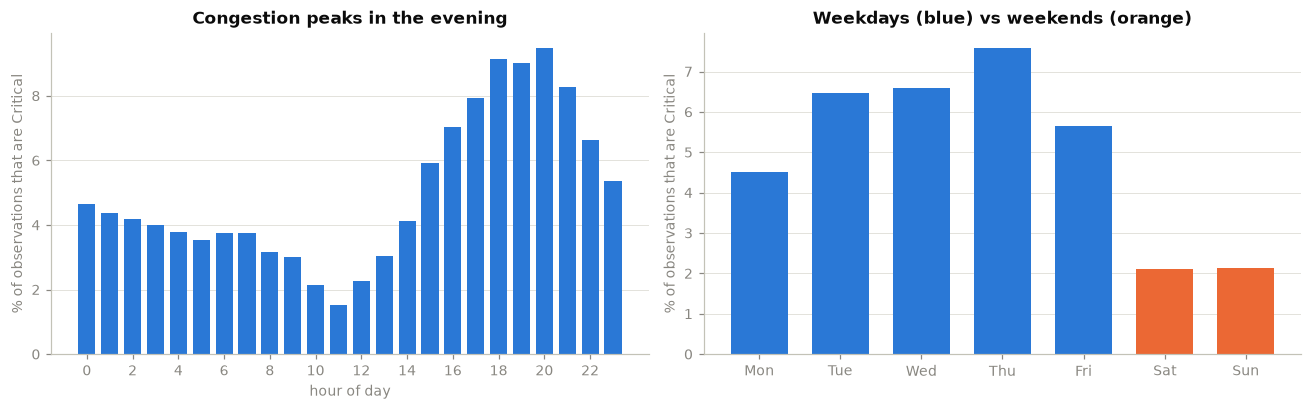

by hour:
timestamp
0     4.66
1     4.36
2     4.20
3     4.01
4     3.77
5     3.52
6     3.74
7     3.76
8     3.15
9     2.99
10    2.13
11    1.53
12    2.26
13    3.03
14    4.12
15    5.91
16    7.02
17    7.94
18    9.15
19    9.03
20    9.48
21    8.26
22    6.62
23    5.37

by day:
Mon    4.52
Tue    6.46
Wed    6.59
Thu    7.58
Fri    5.65
Sat    2.11
Sun    2.12


In [22]:
# Rate = what share of that hour's observations are Critical.
by_hour = (critical.groupby(critical["timestamp"].dt.hour).size()
           / features.groupby(features["timestamp"].dt.hour).size() * 100)

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_day = (critical.groupby(critical["timestamp"].dt.dayofweek).size()
          / features.groupby(features["timestamp"].dt.dayofweek).size() * 100)
by_day.index = days

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].bar(by_hour.index, by_hour.to_numpy(), color=BLUE, width=0.75)
axes[0].set_xlabel("hour of day")
axes[0].set_ylabel("% of observations that are Critical")
axes[0].set_title("Congestion peaks in the evening")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, axis="y")

# Weekends coloured separately - the difference is the point of the chart.
colours = [BLUE] * 5 + [ORANGE] * 2
axes[1].bar(days, by_day.to_numpy(), color=colours, width=0.7)
axes[1].set_ylabel("% of observations that are Critical")
axes[1].set_title("Weekdays (blue) vs weekends (orange)")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

print("by hour:"); print(by_hour.round(2).to_string())
print("\nby day:"); print(by_day.round(2).to_string())

Both patterns are strong and sensible:

- **Time of day:** a clear low around 11:00 (1.5%) and a peak at 18:00–21:00
  (9.5%) — a **6× swing**. Evening peak, as you would expect on a research network
  carrying campus traffic.
- **Day of week:** Thursday 7.6% versus Saturday and Sunday 2.1% — a **3.6×**
  difference.

This is a good sign for the modelling: the cyclical hour-of-day and day-of-week
features built in notebook 02 clearly carry real signal.

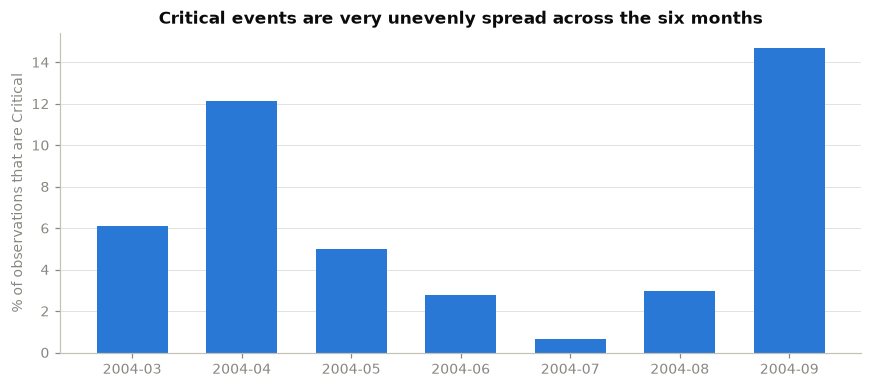

timestamp
2004-03     6.13
2004-04    12.14
2004-05     5.00
2004-06     2.77
2004-07     0.67
2004-08     2.96
2004-09    14.68
Freq: M

Note: September covers only 10 days, so treat it as a partial month.


In [23]:
by_month = (critical.groupby(critical["timestamp"].dt.to_period("M")).size()
            / features.groupby(features["timestamp"].dt.to_period("M")).size() * 100)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar([str(p) for p in by_month.index], by_month.to_numpy(), color=BLUE, width=0.65)
ax.set_ylabel("% of observations that are Critical")
ax.set_title("Critical events are very unevenly spread across the six months")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

print(by_month.round(2).to_string())
print("\nNote: September covers only 10 days, so treat it as a partial month.")

This is the plot that matters most for the split decision.

July has **0.67%** Critical observations. April has **12.1%** and September
**14.7%** — an **18× difference** between the calmest and busiest month.

Because the thresholds are percentiles over the whole series, a month that is
quiet relative to the rest gets almost no Critical labels at all, and a busy month
gets far more than its share. Any split that puts April on one side and July on
the other gives the model wildly different class balances in training and testing.

(September is only 10 days, so its rate is less reliable than the others.)

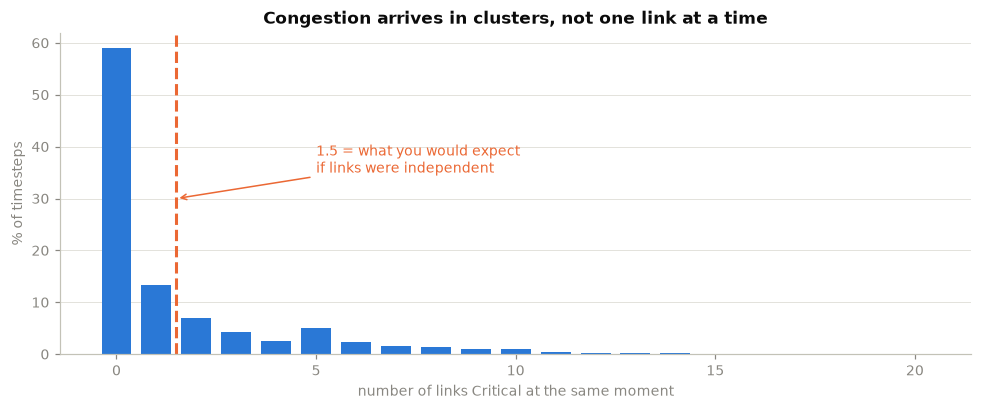

timesteps with no link Critical    : 59.0%
timesteps with 5+ links Critical   : 14.0%
average links Critical per timestep: 1.50


In [24]:
# Do many links go Critical at the same moment, or one at a time?
is_critical = features.assign(c=features["congestion"] == "Critical")
per_timestep = is_critical.pivot_table(index="timestamp", columns="link", values="c").sum(axis=1)

counts = per_timestep.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(counts.index, counts.to_numpy() / len(per_timestep) * 100,
       color=BLUE, width=0.75)
ax.axvline(1.5, color=ORANGE, linewidth=2, linestyle="--")
ax.annotate("1.5 = what you would expect\nif links were independent",
            xy=(1.5, 30), xytext=(5, 35), color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=ORANGE))
ax.set_xlabel("number of links Critical at the same moment")
ax.set_ylabel("% of timesteps")
ax.set_title("Congestion arrives in clusters, not one link at a time")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()

print(f"timesteps with no link Critical    : {(per_timestep == 0).mean() * 100:.1f}%")
print(f"timesteps with 5+ links Critical   : {(per_timestep >= 5).mean() * 100:.1f}%")
print(f"average links Critical per timestep: {per_timestep.mean():.2f}")

If each link were independently Critical 5% of the time, we would expect about 1.5
links Critical at any moment, and simultaneous fives would be vanishingly rare.

Instead: **59% of timesteps have no Critical link at all**, and **14% have five or
more at once**. The average still works out to 1.5 — it has to, that is how
percentiles work — but the distribution is nothing like independent.

This reinforces Part 4. Congestion is a **network-level event**, not a per-link
accident, which is precisely the situation rerouting is meant to address.

## Part 6 — Summary, and what is still unresolved

### What we found

1. **"Regime shift" was the wrong description.** The median utilisation is flat all
   six months. What changes is the tail.
2. **It is one route, one direction.** Five links forming a single west-bound path
   (Chicago → Indianapolis → Kansas City → Denver → Sunnyvale → Los Angeles). The
   same links east-bound are unaffected. This is consistent with a small number of
   very large one-way transfers, not a general traffic increase.
3. **It switches on and off daily,** rather than shifting once. Some days only part
   of the corridor is active.
4. **Two distinct flows, confirmed in the raw OD data** (Part 2f):
   `CHINng->HSTNng` on 8 April and `CHINng->LOSAng` on 10 April, each >5 Gbps and
   150–575× its normal level. Their routes explain exactly which links lit up on
   which day.
5. **September has a second, smaller episode** running east-bound, but it is
   structurally different: a fan-out from `STTLng` to several destinations rather
   than one large transfer, and ~13× smaller. So these are a recurring *type* of
   event, not a one-off.
6. **Congestion is clustered,** in time (evening, weekdays) and across links
   (correlated along paths). 14% of timesteps have 5+ links Critical at once.
7. **Correlations are stronger without the bursts,** not weaker — the episode
   disrupts the network's normal shared daily rhythm.

### What we cannot answer

- **Two of the three transitions happen inside data gaps.** We know the surge began
  abruptly on 8 April. We do not know how the first burst ended or how the second
  began, because both occurred during missing days.
- **`ATLAng->ATLA-M5` reads exactly zero for all of April** and is zero 13% of the
  time overall. Unexplained.
- **The routing matrix is a 2003 snapshot applied to 2004 traffic.** If Abilene's
  routing changed during the period — which the April drop-outs hint at — our link
  loads would be wrong in a way this data cannot reveal. Worth stating whenever the
  numbers are presented.
- **What caused the transfers.** Part 2f identifies the PoP pairs involved and
  nothing further. This dataset cannot say who sent the traffic or why, and we do
  not speculate.

### For the split decision (next notebook)

Not deciding here, but the constraints are now clear:

- The busy episodes sit in **April–May**, with a second in **September**. A naive
  chronological split puts almost all the extreme behaviour in training and almost
  none in test, or the reverse.
- The Critical rate ranges from **0.67% (July) to 14.7% (September)** — an 18×
  swing in class balance depending on where the boundary falls.
- Thresholds must be refit on whichever window becomes the training set (notebook
  02), and that choice visibly changes what "Critical" means.
- Whatever we choose, the honest framing is that the test set contains a **genuinely
  different traffic mix** — which is realistic for a real network, and worth
  reporting rather than engineering away.